In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# scikit-learn modules
from sklearn.model_selection import train_test_split # for splitting the data
from sklearn.metrics import mean_squared_error # for calculating the cost function
from sklearn.tree import DecisionTreeRegressor # for building the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Initializing the Decision Tree Regression model
from sklearn.ensemble import RandomForestRegressor

In [2]:
# load data
df_clean = pd.read_csv("data/MLreadydata.csv")

In [3]:
# split in trainings und testdata

y = df_clean['price']

# Features: alle Spalten außer 'price'
X = df_clean.drop(columns=['price'])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Modell: Decision Tree
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5}
Test R²: 0.0895 | Test MSE: 642680.4908 | MAE: 55.8904 | MedAE: 14.5293


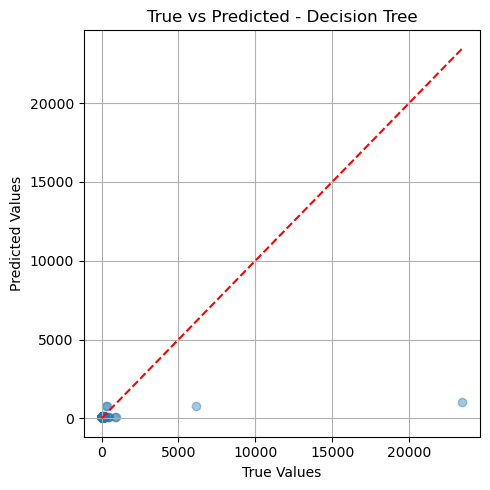


Modell: Random Forest
Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
Test R²: 0.0539 | Test MSE: 667822.0387 | MAE: 48.7181 | MedAE: 6.3691


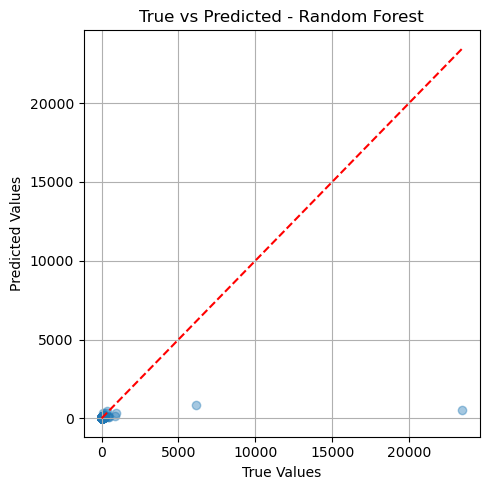


Modell: Gradient Boosting
Best Params: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01}
Test R²: 0.0106 | Test MSE: 698393.7333 | MAE: 53.3893 | MedAE: 12.0076


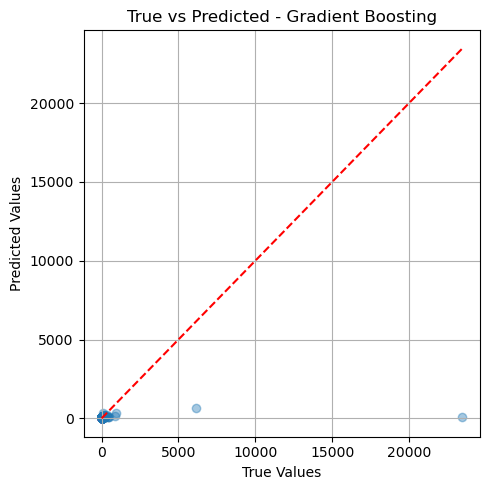


Modell: XGBoost
Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.01}
Test R²: 0.0408 | Test MSE: 677109.6199 | MAE: 48.8249 | MedAE: 7.4928


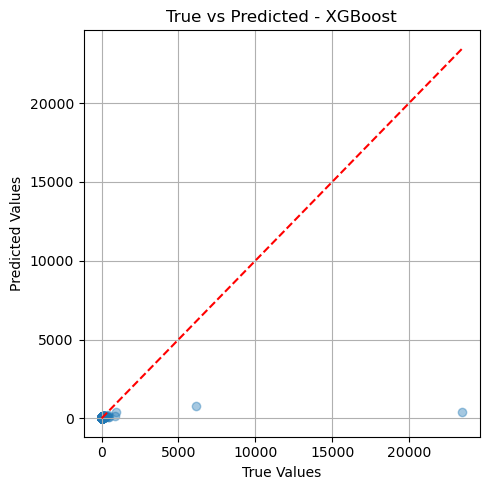


Modell: Linear Regression
Best Params: n/a
Test R²: 0.0721 | Test MSE: 655024.0068 | MAE: 54.5957 | MedAE: 13.2441


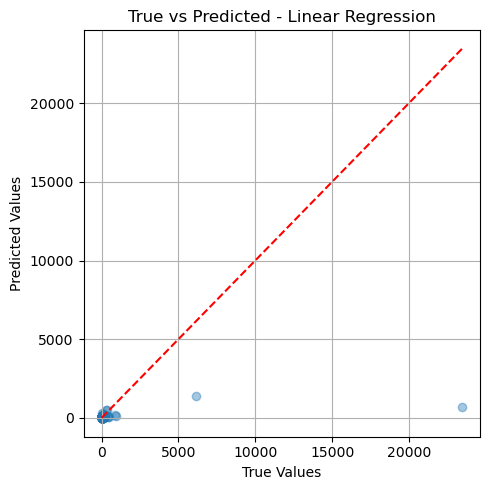


Modellvergleich:
              Modell                                        Best Params  \
0      Decision Tree  {'min_samples_split': 5, 'min_samples_leaf': 4...   
1      Random Forest  {'n_estimators': 100, 'min_samples_split': 10,...   
2  Gradient Boosting  {'n_estimators': 100, 'max_depth': 10, 'learni...   
3            XGBoost  {'subsample': 0.8, 'n_estimators': 200, 'max_d...   
4  Linear Regression                                                n/a   

      CV R²   Test R²       Test MSE        MAE      MedAE  
0  0.140577  0.089537  642680.490809  55.890448  14.529324  
1  0.336007  0.053920  667822.038713  48.718140   6.369093  
2 -0.015917  0.010610  698393.733318  53.389257  12.007567  
3  0.175167  0.040763  677109.619933  48.824882   7.492783  
4       n/a  0.072050  655024.006759  54.595720  13.244095  


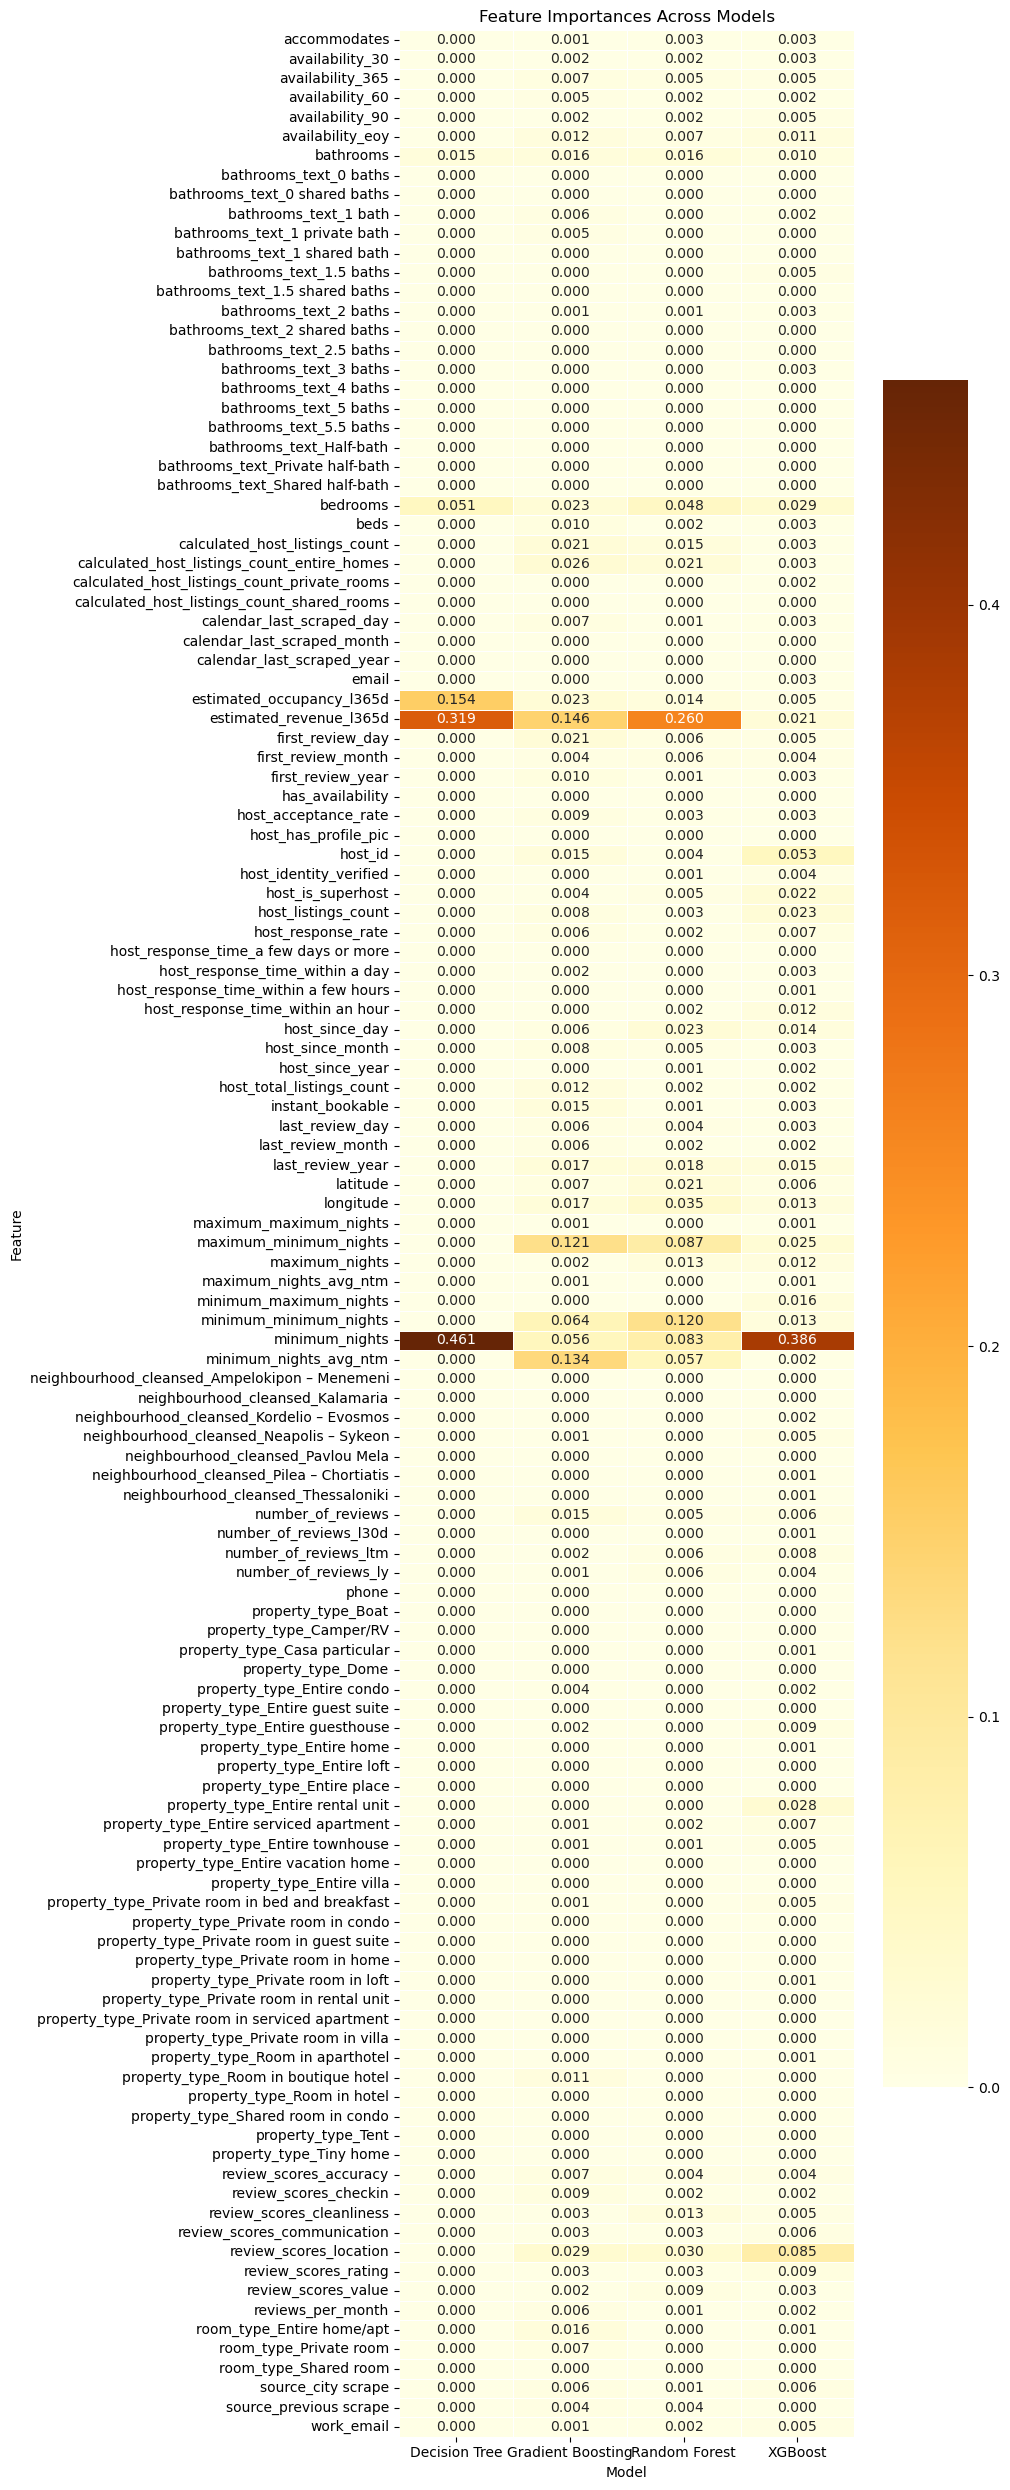

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Modell-Definitionen mit Parametern
models = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=0),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=0),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=0, verbosity=0),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 10],
            "subsample": [0.8, 1.0]
        }
    },
    "Linear Regression": {
        "model": LinearRegression(),
        "params": None  # Kein Hyperparameter-Tuning nötig
    }
}

results = []
feature_importances_all = []

# Modelltraining und Bewertung
for name, config in models.items():
    print(f"\nModell: {name}")
    
    if config["params"] is not None:
        search = RandomizedSearchCV(
            estimator=config["model"],
            param_distributions=config["params"],
            n_iter=10,
            cv=5,
            scoring='r2',
            random_state=0,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
        cv_score = search.best_score_
    else:
        config["model"].fit(X_train, y_train)
        best_model = config["model"]
        best_params = "n/a"
        cv_score = "n/a"

    # Vorhersage und Bewertung
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    print(f"Best Params: {best_params}")
    print(f"Test R²: {r2:.4f} | Test MSE: {mse:.4f} | MAE: {mae:.4f} | MedAE: {medae:.4f}")

    results.append({
        "Modell": name,
        "Best Params": best_params,
        "CV R²": cv_score,
        "Test R²": r2,
        "Test MSE": mse,
        "MAE": mae,
        "MedAE": medae
    })

    # Feature Importances (falls vorhanden)
    if hasattr(best_model, "feature_importances_"):
        fi = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": best_model.feature_importances_,
            "Model": name
        })
        feature_importances_all.append(fi)

    # Plot: True vs. Predicted
    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"True vs Predicted - {name}")
    plt.grid()
    plt.tight_layout()
    plt.show()

# -----------------------------
# Gesamtergebnis
results_df = pd.DataFrame(results)
print("\nModellvergleich:")
print(results_df)

# Als CSV speichern
results_df.to_csv("modellvergleich_ergebnisse.csv", index=False)

# -----------------------------
# Feature Importances als Heatmap
if feature_importances_all:
    all_importances = pd.concat(feature_importances_all)
    pivot = all_importances.pivot_table(index="Feature", columns="Model", values="Importance")
    plt.figure(figsize=(10, 25))
    sns.heatmap(pivot, cmap="YlOrBr", annot=True, fmt=".3f", linewidths=0.5)
    plt.title("Feature Importances Across Models")
    plt.tight_layout()
    plt.show()